In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ============================================================================
# RUN THIS CELL FIRST TO DEBUG YOUR FRAME STRUCTURE
# ============================================================================

import os

#SCAN_PATH = "/content/drive/MyDrive/3RScan/3RScan/19eda6f4-55aa-29a0-8893-8eac3a4d8193"
SCAN_PATH = "/content/drive/MyDrive/3RScan/3RScan/2e36955d-e133-204c-90da-122ae14d42a3"

print("Checking scan structure...\n")

# Check if scan path exists
print(f"Scan path exists: {os.path.exists(SCAN_PATH)}")

# Check what's in the scan directory
if os.path.exists(SCAN_PATH):
    print(f"\nContents of scan directory:")
    for item in sorted(os.listdir(SCAN_PATH)):
        item_path = os.path.join(SCAN_PATH, item)
        if os.path.isdir(item_path):
            print(f"  [DIR]  {item}")
        else:
            print(f"  [FILE] {item}")

# Check sequence directory
sequence_dir = os.path.join(SCAN_PATH, "sequence")
print(f"\nSequence directory exists: {os.path.exists(sequence_dir)}")

if os.path.exists(sequence_dir):
    all_files = os.listdir(sequence_dir)
    print(f"\nTotal files in sequence: {len(all_files)}")

    # Categorize files
    images = [f for f in all_files if f.endswith(('.jpg', '.png', '.jpeg'))]
    poses = [f for f in all_files if f.endswith('.txt')]

    print(f"\nImage files: {len(images)}")
    print(f"Pose files: {len(poses)}")

    # Show first few examples
    print(f"\nFirst 10 files:")
    for f in sorted(all_files)[:10]:
        print(f"  {f}")

    # Check specific patterns
    print(f"\nChecking file patterns:")

    # Pattern 1: frame.XXXXXX.jpg and frame.XXXXXX.pose.txt
    pattern1_images = [f for f in images if f.startswith('frame.') and '.' in f]
    print(f"  Pattern 'frame.XXXXXX.jpg': {len(pattern1_images)}")

    # Pattern 2: XXXXXX.jpg (just numbers)
    pattern2_images = [f for f in images if f.split('.')[0].isdigit()]
    print(f"  Pattern 'XXXXXX.jpg': {len(pattern2_images)}")

    # Pattern 3: color/depth patterns
    color_images = [f for f in images if 'color' in f.lower()]
    print(f"  Pattern with 'color': {len(color_images)}")

    # Show examples of each pattern found
    if pattern1_images:
        print(f"\n  Example pattern 1: {pattern1_images[0]}")
    if pattern2_images:
        print(f"  Example pattern 2: {pattern2_images[0]}")
    if color_images:
        print(f"  Example color: {color_images[0]}")

    # Check pose file patterns
    pose_patterns = {}
    for pose_file in poses[:20]:  # Check first 20
        parts = pose_file.split('.')
        pattern = '.'.join(parts[:-1]) if len(parts) > 1 else pose_file
        pose_patterns[pattern] = pose_patterns.get(pattern, 0) + 1

    print(f"\nPose file patterns:")
    for pattern, count in list(pose_patterns.items())[:5]:
        print(f"  {pattern}.*: {count} files")

else:
    print("\n❌ Sequence directory not found!")
    print("\nLooking for alternative directories...")

    # Check for other common directory names
    alternatives = ['frames', 'images', 'color', 'rgb', 'data']
    for alt in alternatives:
        alt_path = os.path.join(SCAN_PATH, alt)
        if os.path.exists(alt_path):
            print(f"  Found: {alt}/")

Checking scan structure...

Scan path exists: True

Contents of scan directory:
  [FILE] _info.txt
  [FILE] labels.instances.annotated.v2.ply
  [FILE] mesh.refined.0.010000.segs.v2.json
  [FILE] mesh.refined.mtl
  [FILE] mesh.refined.v2.obj
  [FILE] mesh.refined_0.png
  [DIR]  output
  [FILE] semseg.v2.json

Sequence directory exists: False

❌ Sequence directory not found!

Looking for alternative directories...


In [3]:
# Install required packages
!pip install -q torch torchvision
!pip install -q transformers
!pip install -q Pillow
!pip install -q matplotlib
!pip install -q tqdm
!pip install -q scikit-learn

print("✅ Installation complete!")

✅ Installation complete!


In [4]:
# Imports
import os
import torch
import numpy as np
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm
import pickle
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports complete!")
print(f"Using device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ Imports complete!
Using device: GPU


In [5]:
# Configuration
BASE_PATH = "/content/drive/MyDrive/3RScan/3RScan"

SCAN_IDS = [
    "2e36955d-e133-204c-90da-122ae14d42a3",
    "2e36954f-e133-204c-9320-34d52370eb4d",
    "2e36954d-e133-204c-92aa-5cf8c2f8b46f",
    "2e36954b-e133-204c-92ad-1a66c6f63e1a",
    "2e36952b-e133-204c-911e-7644cb34e8b2"
]

# Where to save embeddings
EMBEDDINGS_CACHE = "/content/embeddings_cache.pkl"

# Similarity threshold (0-1, higher = more strict)
SIMILARITY_THRESHOLD = 0.25  # Adjust this based on testing

print(f"✅ Configuration set for {len(SCAN_IDS)} scans")

✅ Configuration set for 5 scans


In [6]:
def load_all_images(base_path, scan_ids):
    """
    Load all images from the color folders of all scans.
    Returns a list of dicts with image path, scan_id, and frame number.
    """
    all_images = []

    print("Loading images from all scans...")
    for scan_id in tqdm(scan_ids, desc="Scans"):
        color_dir = os.path.join(base_path, scan_id, "output", "color")

        if not os.path.exists(color_dir):
            print(f"⚠️ Warning: {color_dir} not found, skipping...")
            continue

        # Get all image files
        image_files = sorted([f for f in os.listdir(color_dir)
                            if f.endswith(('.jpg', '.png', '.jpeg'))])

        for img_file in image_files:
            img_path = os.path.join(color_dir, img_file)

            # Extract frame number from filename
            frame_num = img_file.split('.')[0]

            all_images.append({
                'path': img_path,
                'scan_id': scan_id,
                'frame': frame_num,
                'filename': img_file
            })

    print(f"\n✅ Loaded {len(all_images)} images from {len(scan_ids)} scans")

    # Show statistics
    for scan_id in scan_ids:
        count = len([img for img in all_images if img['scan_id'] == scan_id])
        print(f"  - {scan_id[:8]}...: {count} images")

    return all_images

# Load all images
image_database = load_all_images(BASE_PATH, SCAN_IDS)

Loading images from all scans...


Scans:   0%|          | 0/5 [00:00<?, ?it/s]


✅ Loaded 40 images from 5 scans
  - 2e36955d...: 10 images
  - 2e36954f...: 7 images
  - 2e36954d...: 9 images
  - 2e36954b...: 7 images
  - 2e36952b...: 7 images


In [7]:
# Load CLIP model
print("Loading CLIP model...")
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print(f"✅ CLIP model loaded on {device}")

Loading CLIP model...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP model loaded on cuda


In [8]:
def generate_image_embeddings(image_database, model, processor, device, batch_size=32):
    """
    Generate CLIP embeddings for all images.
    Processes in batches for efficiency.
    """
    embeddings = []

    print(f"Generating embeddings for {len(image_database)} images...")
    print(f"Batch size: {batch_size}")

    model.eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(image_database), batch_size), desc="Batches"):
            batch = image_database[i:i+batch_size]

            # Load images
            images = []
            for item in batch:
                try:
                    img = Image.open(item['path']).convert('RGB')
                    images.append(img)
                except Exception as e:
                    print(f"\n⚠️ Error loading {item['path']}: {e}")
                    # Add zero embedding for failed images
                    embeddings.append(np.zeros(512))
                    continue

            if not images:
                continue

            # Process batch
            inputs = processor(images=images, return_tensors="pt", padding=True).to(device)

            # Get embeddings
            image_features = model.get_image_features(**inputs)

            # Normalize embeddings
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # Convert to numpy and store
            batch_embeddings = image_features.cpu().numpy()
            embeddings.extend(batch_embeddings)

    return np.array(embeddings)


# Check if embeddings are cached
if os.path.exists(EMBEDDINGS_CACHE):
    print("📦 Loading cached embeddings...")
    with open(EMBEDDINGS_CACHE, 'rb') as f:
        cache_data = pickle.load(f)
        image_embeddings = cache_data['embeddings']
        cached_database = cache_data['database']

    # Verify cache matches current database
    if len(cached_database) == len(image_database):
        print(f"✅ Loaded {len(image_embeddings)} cached embeddings")
    else:
        print("⚠️ Cache mismatch, regenerating embeddings...")
        image_embeddings = generate_image_embeddings(image_database, model, processor, device)

        # Save to cache
        with open(EMBEDDINGS_CACHE, 'wb') as f:
            pickle.dump({'embeddings': image_embeddings, 'database': image_database}, f)
        print(f"💾 Saved embeddings to cache")
else:
    # Generate embeddings
    image_embeddings = generate_image_embeddings(image_database, model, processor, device)

    # Save to cache
    print("\n💾 Saving embeddings to cache...")
    with open(EMBEDDINGS_CACHE, 'wb') as f:
        pickle.dump({'embeddings': image_embeddings, 'database': image_database}, f)
    print(f"✅ Saved embeddings to {EMBEDDINGS_CACHE}")

print(f"\n📊 Embedding shape: {image_embeddings.shape}")

Generating embeddings for 40 images...
Batch size: 32


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


💾 Saving embeddings to cache...
✅ Saved embeddings to /content/embeddings_cache.pkl

📊 Embedding shape: (40, 512)


In [19]:
def encode_text_query(text, model, processor, device):
    """
    Encode text query using CLIP.
    """
    inputs = processor(text=[text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return text_features.cpu().numpy()[0]


def search_images(query_embedding, image_embeddings, image_database, top_k=6):
    """
    Search for top-k most similar images.
    Returns indices, similarities, and image info.
    """
    # Compute cosine similarities
    similarities = cosine_similarity([query_embedding], image_embeddings)[0]

    # Get top-k indices
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_similarities = similarities[top_indices]

    # Get image info
    results = []
    for idx, sim in zip(top_indices, top_similarities):
        results.append({
            'index': idx,
            'similarity': sim,
            'image_info': image_database[idx]
        })

    return results



def display_results(results, query_text):
    """
    Display query results in a nice grid.
    Layout: Best match on left (full height), 5 other matches in 3x2 grid on right
    """
    n_results = len(results)

    # Create figure with custom layout - 3 rows to accommodate 6 images
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

    fig.suptitle(f'Query: "{query_text}"', fontsize=16, fontweight='bold', y=0.98)

    for i, result in enumerate(results):
        img_info = result['image_info']
        similarity = result['similarity']

        # Determine subplot position
        if i == 0:
            # Best match takes up left column (all 3 rows)
            ax = fig.add_subplot(gs[:, 0])
        else:
            # Others in 3x2 grid on the right (indices 1-5)
            # Map i=1,2,3,4,5 to positions in right 3x2 grid
            right_index = i - 1  # 0,1,2,3,4
            row = right_index // 2  # 0,0,1,1,2
            col = right_index % 2 + 1  # 1,2,1,2,1
            ax = fig.add_subplot(gs[row, col])

        # Load and display image
        try:
            img = Image.open(img_info['path'])
            ax.imshow(img)
            ax.axis('off')

            # Title with similarity score
            title = f"{'🎯 BEST MATCH' if i == 0 else f'Match {i}'}\\n"
            title += f"Similarity: {similarity:.3f}\\n"
            title += f"Scan: ...{img_info['scan_id'][-8:]}\\n"
            title += f"Frame: {img_info['frame']}"

            fontsize = 14 if i == 0 else 10
            fontweight = 'bold' if i == 0 else 'normal'

            ax.set_title(title, fontsize=fontsize, fontweight=fontweight,
                        bbox=dict(boxstyle='round', facecolor='wheat' if i == 0 else 'lightblue', alpha=0.8))

        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading image\\n{str(e)}',
                   ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()


print("✅ Fixed display_results function loaded!")



def is_good_match(best_similarity, threshold=SIMILARITY_THRESHOLD):
    """
    Determine if the best match is good enough.
    """
    return best_similarity >= threshold


print("✅ Query system ready!")

✅ Fixed display_results function loaded!
✅ Query system ready!


In [20]:
# Follow-up question templates
FOLLOWUP_QUESTIONS = [
    "Can you describe the colors or lighting in the scene?",
    "What objects or furniture can you see in the image?",
    "Is this an indoor or outdoor scene? What room type?",
    "Are there any distinctive features or landmarks visible?",
    "Can you describe the viewing angle or camera perspective?",
    "What's the overall atmosphere or style of the space?"
]

def get_followup_question(conversation_history):
    """
    Get an appropriate follow-up question based on conversation length.
    """
    num_questions_asked = len([msg for msg in conversation_history if msg.startswith("🤔")])

    if num_questions_asked < len(FOLLOWUP_QUESTIONS):
        return FOLLOWUP_QUESTIONS[num_questions_asked]
    else:
        return "Can you provide any other details about what you're looking for?"


def run_interactive_chat():
    """
    Main interactive chat loop with mandatory questions before showing results.
    Always asks 2+ questions, then shows results, then allows refinement.
    """
    print("="*80)
    print("🔍 CLIP Image Localization System - Enhanced Version")
    print("="*80)
    print(f"\n📊 Database: {len(image_database)} images from {len(SCAN_IDS)} scans")
    print(f"🎯 Similarity threshold: {SIMILARITY_THRESHOLD:.2f}")
    print("\n💡 How it works:")
    print("  1. I'll ask you 2-3 questions to understand what you're looking for")
    print("  2. Then I'll show you the best matches")
    print("  3. You can refine by adding more details")
    print("\n📝 Commands:")
    print("  • 'show results' - Skip remaining questions and show matches now")
    print("  • 'reset' - Start a completely new search")
    print("  • 'quit' - Exit the system")
    print("\n" + "="*80)

    conversation_history = []
    combined_query = ""
    min_questions = 2  # Minimum questions to ask before showing results
    questions_asked = 0
    results_shown = False

    while True:
        # Get user input
        if not conversation_history:
            user_input = input("\n🔎 What are you looking for? > ").strip()
        else:
            user_input = input("\n💭 > ").strip()

        # Check for exit commands
        if user_input.lower() in ['quit', 'exit', 'q']:
            print("\n👋 Goodbye!")
            break

        # Check for reset
        if user_input.lower() == 'reset':
            print("\n🔄 Starting new search...\n" + "="*80)
            conversation_history = []
            combined_query = ""
            questions_asked = 0
            results_shown = False
            continue

        # Check for forced show results
        if user_input.lower() in ['show results', 'show', 'display', 'show me']:
            if not conversation_history or len([msg for msg in conversation_history if not msg.startswith("🤔")]) == 0:
                print("⚠️ Please describe what you're looking for first!")
                continue
            # Force showing results by setting questions_asked
            questions_asked = min_questions
            # Don't add "show results" command to query
            # Just proceed to display with current query
            print("\n🔄 Analyzing current description...")
        else:
            if not user_input:
                print("⚠️ Please enter a description.")
                continue

            # Add to conversation history
            conversation_history.append(user_input)

        # Build combined query from user messages only (exclude system questions)
        user_messages = [msg for msg in conversation_history if not msg.startswith("🤔")]
        combined_query = " ".join(user_messages)

        # Encode query and search
        query_embedding = encode_text_query(combined_query, model, processor, device)
        results = search_images(query_embedding, image_embeddings, image_database, top_k=6)
        best_similarity = results[0]['similarity']

        # Decide what to do based on conversation state
        if questions_asked < min_questions and not results_shown:
            # Still in question phase - ask another clarifying question
            print(f"✓ Got it! (Current best match: {best_similarity:.3f})")

            followup = get_followup_question(conversation_history)
            conversation_history.append(f"🤔 {followup}")
            questions_asked += 1

            print(f"\n{followup}")
            print(f"💡 Or type 'show results' to see matches now")

        else:
            # Ready to show results (either enough questions asked, or user forced display, or refinement)
            if results_shown:
                print(f"\n🔄 Refining search... (best similarity: {best_similarity:.3f})")
            else:
                print(f"\n✅ Analyzing complete! (best similarity: {best_similarity:.3f})")

            display_results(results, combined_query)
            results_shown = True

            # Keep conversation going for refinement
            print("\n" + "─"*80)
            print("💬 Continue the conversation to refine results:")
            print("  Examples:")
            print("    • 'the lamp should be white, not black'")
            print("    • 'show me from a different angle'")
            print("    • 'the chair should be more visible'")
            print("    • 'I want a wider view of the room'")
            print("\n  Or type 'reset' to start over, 'quit' to exit")
            print("─"*80)


print("✅ Enhanced interactive chat ready!")
print("💡 Run: run_interactive_chat()")


✅ Enhanced interactive chat ready!
💡 Run: run_interactive_chat()


🔍 CLIP Image Localization System - Enhanced Version

📊 Database: 40 images from 5 scans
🎯 Similarity threshold: 0.25

💡 How it works:
  1. I'll ask you 2-3 questions to understand what you're looking for
  2. Then I'll show you the best matches
  3. You can refine by adding more details

📝 Commands:
  • 'show results' - Skip remaining questions and show matches now
  • 'reset' - Start a completely new search
  • 'quit' - Exit the system


🔎 What are you looking for? > An armchair with a cushion next to a wooden side table and a decorative lamp
✓ Got it! (Current best match: 0.298)

Can you describe the colors or lighting in the scene?
💡 Or type 'show results' to see matches now

💭 > the table is dark wooden brown
✓ Got it! (Current best match: 0.307)

What objects or furniture can you see in the image?
💡 Or type 'show results' to see matches now

💭 > there is an armchair, a side table, and a floor mat

✅ Analyzing complete! (best similarity: 0.321)


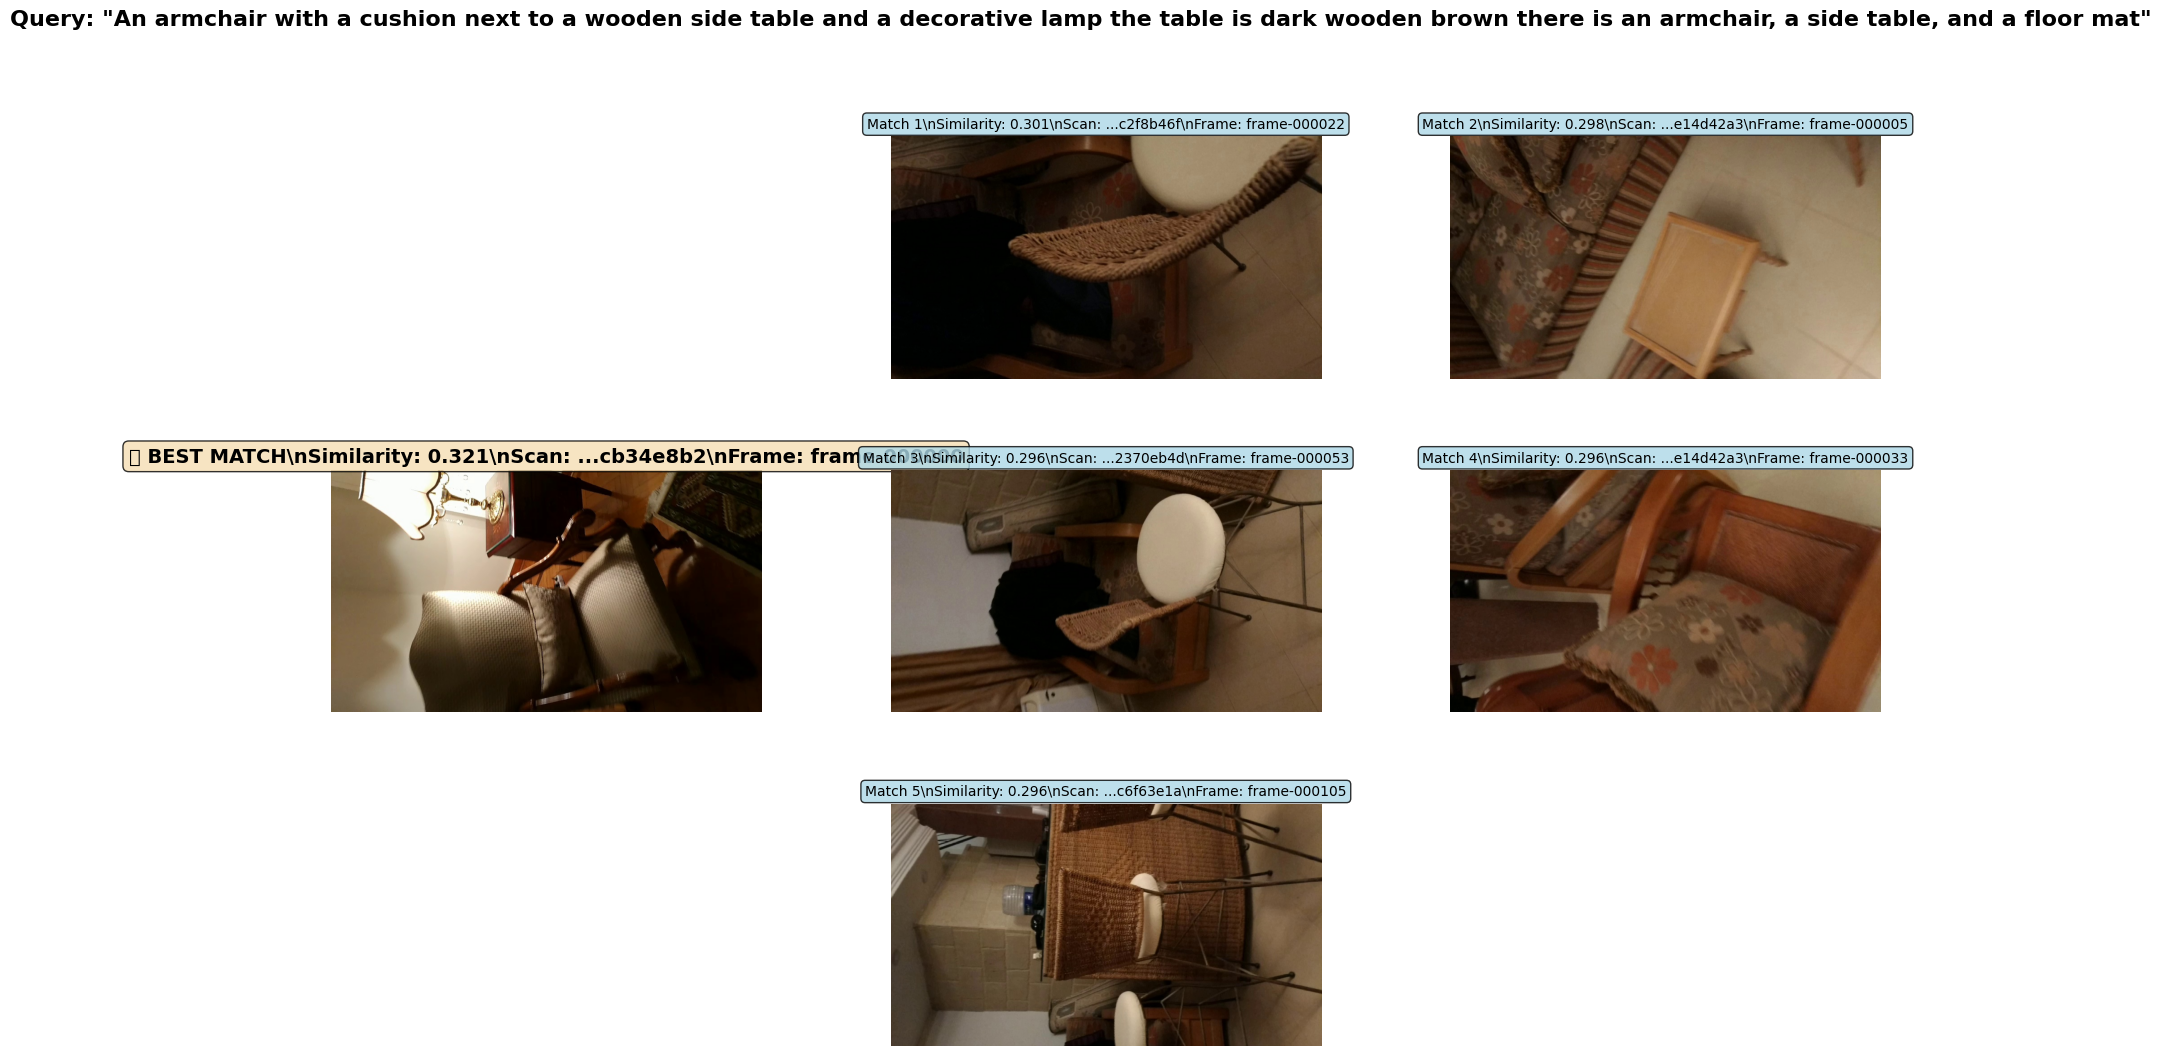


────────────────────────────────────────────────────────────────────────────────
💬 Continue the conversation to refine results:
  Examples:
    • 'the lamp should be white, not black'
    • 'show me from a different angle'
    • 'the chair should be more visible'
    • 'I want a wider view of the room'

  Or type 'reset' to start over, 'quit' to exit
────────────────────────────────────────────────────────────────────────────────


In [ ]:
# Run the interactive chat
run_interactive_chat()